# Insurance Churn Analysis

Objective:
Built Insurance Renewal Funnel Analysis using Python, Pandas, Seaborn and Logistic Regression.

Key findings:
- 26-35 , 56+ Age group had highest churn
- Child Care policy showed higher drop-off
- High premium customers more likely to churn

Built predictive model assigning churn probability and risk segment.
Predict customers likely to not renew insurance policies.
Highest churn age group = ?   26-35 , 56+ age groups
Highest churn policy type = ?  Child Care, Churn % = 22%
Premium effect on churn = ? Medium & High Premium paying customers churn more
Model created = Logistic Regression
Output = churn probability score


In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt

In [7]:
print("Libraries imported successfully")

Libraries imported successfully


In [11]:
print(pd.__version__)
print(np.__version__)
print(sns.__version__)
print(matplotlib.__version__)

3.0.2
2.4.4
0.13.2
3.10.9


Load datasets

In [ ]:

customer_profiles = pd.read_csv(r"C:\Users\akank\OneDrive\Desktop\Business-Data-Projects\StarHealth\Health_Insurance\Input_Dataset\customer_profiles.csv")
policy_details = pd.read_csv(r"C:\Users\akank\OneDrive\Desktop\Business-Data-Projects\StarHealth\Health_Insurance\Input_Dataset\policy_details.csv")
portal_web_logs = pd.read_csv(r"C:\Users\akank\OneDrive\Desktop\Business-Data-Projects\StarHealth\Health_Insurance\Input_Dataset\portal_web_logs.csv")

print("Customer Profiles")
display(customer_profiles.head())
customer_profiles.info()
customer_profiles.shape
customer_profiles.columns
print("Policy Details")
display(policy_details.head())
print("Portal Web Logs")
display(portal_web_logs.head())

Customer Profiles


,age,sex,bmi,children,smoker,region,expenses,customer_id
0,19,female,27.9,0,yes,southwest,16884.92,1001
1,18,male,33.8,1,no,southeast,1725.55,1002
2,28,male,33.0,3,no,southeast,4449.46,1003
3,33,male,22.7,0,no,northwest,21984.47,1004
4,32,male,28.9,0,no,northwest,3866.86,1005


<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          1338 non-null   int64  
 1   sex          1338 non-null   str    
 2   bmi          1338 non-null   float64
 3   children     1338 non-null   int64  
 4   smoker       1338 non-null   str    
 5   region       1338 non-null   str    
 6   expenses     1338 non-null   float64
 7   customer_id  1338 non-null   int64  
dtypes: float64(2), int64(3), str(3)
memory usage: 83.8 KB
Policy Details


,customer_id,policy_id,policy_type,expiry_date,premium_amount,payment_status
0,1001,POL_10000,Comprehensive,2026-06-16,13507.94,Pending
1,1002,POL_10001,Comprehensive,2026-06-20,1380.44,Success
2,1003,POL_10002,Women Care,2026-06-16,3559.57,Success
3,1004,POL_10003,Child Care,2026-05-19,17587.58,Pending
4,1005,POL_10004,Comprehensive,2026-06-13,3093.49,Pending


Portal Web Logs


,customer_id,visit_timestamp,page_viewed
0,1003,2026-04-29 19:06:44,Policy_Details
1,1003,2026-04-26 19:06:44,Policy_Details
2,1003,2026-04-28 19:06:44,Dashboard
3,1004,2026-05-01 19:06:44,Eligibility_Check
4,1004,2026-04-27 19:06:44,Policy_Details


Clean dataset 
a) Check Null
b) Check Duplicates
c) Check datatype

In [54]:
customer_profiles.isnull().sum()
customer_profiles.duplicated().sum()
customer_profiles.info()

policy_details.isnull().sum()
policy_details.duplicated().sum()
policy_details.info()

portal_web_logs.isnull().sum()
portal_web_logs.duplicated().sum()
portal_web_logs.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          1338 non-null   int64  
 1   sex          1338 non-null   str    
 2   bmi          1338 non-null   float64
 3   children     1338 non-null   int64  
 4   smoker       1338 non-null   str    
 5   region       1338 non-null   str    
 6   expenses     1338 non-null   float64
 7   customer_id  1338 non-null   int64  
dtypes: float64(2), int64(3), str(3)
memory usage: 83.8 KB
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     1338 non-null   int64  
 1   policy_id       1338 non-null   str    
 2   policy_type     1338 non-null   str    
 3   expiry_date     1338 non-null   str    
 4   premium_amount  1338 non-null   float64
 5   payment_sta

Preview dataset

In [76]:


customer_profiles.head()
#policy_details.head()
# portal_web_logs.head()

,age,sex,bmi,children,smoker,region,expenses,customer_id,age_group
0,19,female,27.9,0,yes,southwest,16884.92,1001,"(18.0, 25.0]"
1,18,male,33.8,1,no,southeast,1725.55,1002,NaN
2,28,male,33.0,3,no,southeast,4449.46,1003,"(25.0, 35.0]"
3,33,male,22.7,0,no,northwest,21984.47,1004,"(25.0, 35.0]"
4,32,male,28.9,0,no,northwest,3866.86,1005,"(25.0, 35.0]"


Save dataset

In [228]:
customer_profiles.to_csv("clean_customer_profiles.csv", index=False)
policy_details.to_csv("clean_policy_details.csv", index=False)
portal_web_logs.to_csv("clean_portal_web_logs.csv", index=False)

Phase 1 : EDA Analysis :
TASK A : AGE GROUP ANALYSIS  : Which age group has highest churn?

TASK B : POLICY TYPE DROP -OFF - Which policy have highest drop-off ?

Task C: Premium Analysis - Do higher premium customers churn more?

TASK D : Co relation


In [229]:
# Age group analysis for churn and retention
policy_details["Renewed"] = policy_details["payment_status"].apply(
    lambda x: "Retention%" if str(x).strip().lower() == "success" else "Churn%"
)

df = pd.merge(customer_profiles, policy_details, on="customer_id")

df["Age_group"] = pd.cut(
    df["age"],
    bins=[18, 25, 35, 45, 55, 100],
    labels=["18-25", "26-35", "36-45", "46-55", "56+"],
    include_lowest=True
)

churn_table = pd.crosstab(
    df["Age_group"],
    df["Renewed"],
    normalize="index"
) * 100

display(churn_table)

Renewed,Churn%,Retention%
Age_group,,
18-25,28.104575,71.895425
26-35,34.328358,65.671642
36-45,29.166667,70.833333
46-55,32.394366,67.605634
56+,34.259259,65.740741



TASK A : Final Analysis
Insights: Analysis by churn age group
* Which age group has highest churn? : 26-35 , 56+ age groups

Business Insights:
Highest churn: 26-35 (~34.3%) and 56+ (~34.2%)
Lowest churn: 18-25 (~27.4%)
Best retention segment: 18-25
Riskier segments for renewal campaigns:
26-35, 56+

Possible business interpretation:

26–35 customers may be more price-sensitive / comparison shoppers.
56+ may need better renewal reminders or agent support.

A concise analyst statement:

Customers in the 26–35 and 56+ age groups exhibit the highest churn rates (~34%), indicating these segments are more likely to lapse policies and should be prioritized for targeted retention campaigns.

In [230]:
# TASK B : Policy Type Drop-off Analysis 
visit_counts = portal_web_logs.groupby("customer_id").size().reset_index(name="visit_count")
policy_df = pd.merge(
    policy_details,
    visit_counts,
    on="customer_id",
    how="left"
)

policy_df["Drop_off"] = (
    (policy_df["visit_count"] > 1) &
    (policy_df["payment_status"].str.lower() == "pending")
)

policy_df["Drop_off"] = policy_df["Drop_off"].map(
    {True: "Yes", False: "No"}
)

policy_dropoff_table = pd.crosstab(
    policy_df["policy_type"],
    policy_df["Drop_off"],
    normalize="index"
)* 100

policy_dropoff_table.columns = pd.MultiIndex.from_product(
    [["Drop_off"], ["Retention %", "Drop-Off %"]]
)


display(policy_dropoff_table)



Drop_off           
                     Retention % Drop-Off %
policy_type                                
Child Care             77.993528  22.006472
Comprehensive          83.333333  16.666667
Family Health Optima   81.843575  18.156425
Women Care             80.000000  20.000000

TASK B : Final Analysis
Policy with highest drop off ? Child Care : 22 %

Defined drop-off customers as users with multiple portal visits and pending payment status. Analysis showed that Child Care policies have the highest drop-off rate at 22%, suggesting stronger renewal/payment friction compared to other policy types.

Business insight

✅ Child Care has the highest drop-off rate (22%)

Interpretation:

Customers interested in Child Care policies revisit the portal multiple times but are more likely to leave with pending payments, indicating friction before payment completion.

Possible reasons:

premium amount too high
customers comparing plans
confusing eligibility/payment flow


In [231]:
# TASK C : Premium Analysis - Do higher premium customers churn more?
df["Premium_group"] = pd.qcut(
    df["premium_amount"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

premium_churn = pd.crosstab(
    df["Premium_group"],
    df["Renewed"],
    normalize="index"
) * 100

premium_churn = premium_churn.rename(
    columns={
        "No": "Churn%",
        "Yes": "Retention%"
    }
)
premium_churn = premium_churn.round(1)

display(premium_churn)

Renewed,Churn%,Retention%
Premium_group,,
Low,29.9,70.1
Medium,33.2,66.8
High,33.8,66.2
Very High,29.0,71.0


TASK C :  Medium & High premium customers churn more
 
Business Insight :
Customers in the High and Medium premium segments show the highest churn rates (~33%), whereas Low and Very High premium customers demonstrate stronger retention (~70%+).

Possible interpretation:

Medium/High premium customers may be more price-sensitive and compare alternatives before renewal.
Very High premium customers may be more committed, perceive higher value, or have stronger insurance dependency.
Low premium customers may face lower financial friction, supporting better renewal rates.


In [232]:
# TASK D : Correlation Analysis - Which factors are most correlated with churn?

df["churn_flag"] = df["Renewed"].map({
                    "Churn%" :1,
                    "Retention%": 0
})
correlation = df.corr(numeric_only=True)["churn_flag"].sort_values()

print(correlation)
# print(df["churn_flag"])

expenses         -0.015201
premium_amount   -0.015201
customer_id      -0.000535
bmi               0.002043
age               0.030235
children          0.058819
churn_flag        1.000000
Name: churn_flag, dtype: float64


Task D : Correlation Analysis weak for numeric values

| Correlation | Strength   |
| ----------- | ---------- |
| 0 to 0.1    | negligible |
| 0.1 to 0.3  | weak       |
| 0.3 to 0.5  | moderate   |
| >0.5        | strong     |

Correlation analysis shows no strong linear relationship between churn and numeric variables such as age, premium amount, expenses, BMI, or children. This suggests churn is likely influenced more by categorical or behavioral factors such as policy type, payment status, or customer engagement patterns.


Phase 2 : Visualization
a) Policy vs Renewal
b) Premium Amount vs Renewal
c) Correlation Heatmap

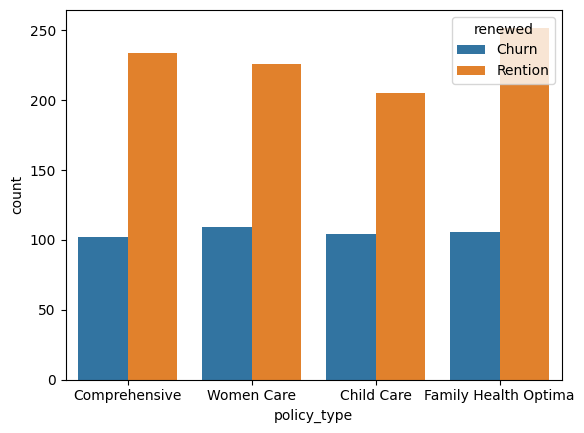

In [156]:
# a) Policy vs Renewal Chart
sns.countplot(data=df, x="policy_type", hue="renewed")
plt.show()

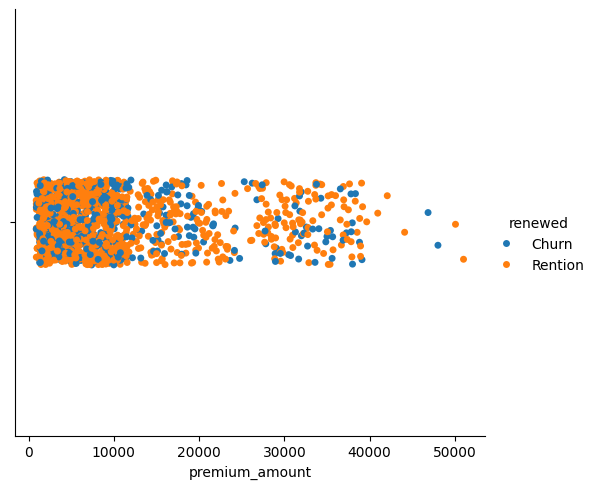

In [196]:
# b) Premium vs Renewal chart
sns.catplot(data=df, x="premium_amount", hue="renewed")
plt.show()

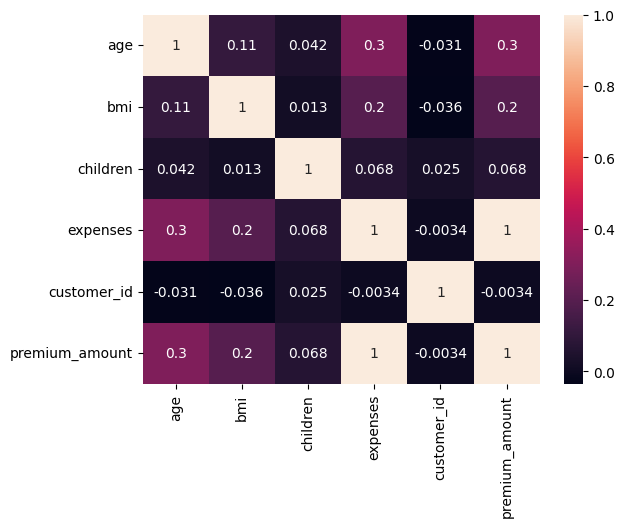

In [197]:
# c) Correlation Heatmap

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

Phase 3: Machine Learning Model (Prediction)
Customer churn prediction model : Can we predict churn before it happens?

Business wants to know:

Who is high risk?
Who should get retention discount?
Who needs reminder calls?

In [235]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df.drop("renewed", axis=1)
y = df["renewed"]
X = pd.get_dummies(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

#Train Logistic regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

df["churn_probability"] = model.predict_proba(X)[:,1]
df["churn_probability"].describe()
# print(df["churn_probability"])

count    1338.000000
mean        0.685387
std         0.461565
min         0.003209
25%         0.004844
50%         0.997878
75%         0.998107
max         0.998682
Name: churn_probability, dtype: float64

Phase 4: Risk Segmentation 
After ML Predction, calculate High risk, low risk customers. Accordingly apply retention campaigns.

Business Use

High-risk customers need immediate retention offers.
Medium-risk customers targeted with reminders.
Low-risk customers require minimal intervention.

In [234]:
def risk(score):
    if score > 0.7:
        return "High Risk"
    elif score > 0.4:
        return "Medium Risk"
    else:
        return "Low Risk"
    

df["risk_segment"] = df["churn_probability"].apply(risk)
df[["customer_id","churn_probability","risk_segment"]].head()
df["risk_segment"].value_counts()


risk_segment
High Risk    917
Low Risk     421
Name: count, dtype: int64

Phase 5 : Final Output

In [236]:

df.to_csv("insurance_churn_output_3.csv", index=False)
insurance_churn_output_file = pd.read_csv(r"C:\Users\akank\OneDrive\Desktop\Business-Data-Projects\StarHealth\Health_Insurance\insurance_churn_output_3.csv")
display(insurance_churn_output_file)



,age,sex,bmi,children,smoker,region,expenses,customer_id,age_group,policy_id,policy_type,expiry_date,premium_amount,payment_status,renewed,Renewed,Age_group,Premium_group,churn_flag,churn_probability,risk_segment
0,19,female,27.9,0,yes,southwest,16884.92,1001,"(10, 20]",POL_10000,Comprehensive,2026-06-16,13507.94,Pending,Churn,Churn%,18-25,Very High,1,0.004867,Low Risk
1,18,male,33.8,1,no,southeast,1725.55,1002,"(10, 20]",POL_10001,Comprehensive,2026-06-20,1380.44,Success,Rention,Retention%,18-25,Low,0,0.997996,High Risk
2,28,male,33.0,3,no,southeast,4449.46,1003,"(20, 30]",POL_10002,Women Care,2026-06-16,3559.57,Success,Rention,Retention%,26-35,Low,0,0.997710,High Risk
3,33,male,22.7,0,no,northwest,21984.47,1004,"(30, 40]",POL_10003,Child Care,2026-05-19,17587.58,Pending,Churn,Churn%,26-35,Very High,1,0.003529,Low Risk
4,32,male,28.9,0,no,northwest,3866.86,1005,"(30, 40]",POL_10004,Comprehensive,2026-06-13,3093.49,Pending,Churn,Churn%,26-35,Low,1,0.003589,Low Risk
5,31,female,25.7,0,no,southeast,3756.62,1006,"(30, 40]",POL_10005,Family Health Optima,2026-05-30,3005.30,Pending,Churn,Churn%,26-35,Low,1,0.004224,Low Risk
6,46,female,33.4,1,no,southeast,8240.59,1007,"(40, 50]",POL_10006,Women Care,2026-06-21,6592.47,Success,Rention,Retention%,46-55,Medium,0,0.998151,High Risk
7,37,female,27.7,3,no,northwest,7281.51,1008,"(30, 40]",POL_10007,Family Health Optima,2026-05-29,5825.21,Success,Rention,Retention%,36-45,Medium,0,0.997688,High Risk
8,37,male,29.8,2,no,northeast,6406.41,1009,"(30, 40]",POL_10008,Family Health Optima,2026-05-30,5125.13,Success,Rention,Retention%,36-45,Medium,0,0.997553,High Risk
9,60,female,25.8,0,no,northwest,28923.14,1010,"(50, 100]",POL_10009,Child Care,2026-06-26,23138.51,Success,Rention,Retention%,56+,Very High,0,0.997994,High Risk
